# 02. KIỂM TRA CHẤT LƯỢNG DỮ LIỆU (DATA QUALITY CHECK)

## MỤC LỤC
1. [Import thư viện & Đọc dữ liệu](#1-import-thư-viện--đọc-dữ-liệu)
2. [Missing Data (Dữ liệu bị thiếu)](#2-missing-data-dữ-liệu-bị-thiếu)
   - 2.1. Thống kê số lượng và tỷ lệ khuyết thiếu
   - 2.2. Đánh giá & Định hướng xử lý (Markdown)
3. [Outliers (Giá trị bất thường)](#3-outliers-giá-trị-bất-thường)
   - 3.1. Kiểm tra điểm số và tương tác bất thường
   - 3.2. Trực quan hóa Outliers bằng Boxplot
   - 3.3. Đánh giá & Định hướng xử lý (Markdown)
4. [Data Imbalance (Mất cân bằng dữ liệu)](#4-data-imbalance-mất-cân-bằng-dữ-liệu)
   - 4.1. Phân tích phân bố biến mục tiêu `final_result`
   - 4.2. Trực quan hóa tỷ lệ các lớp dữ liệu
   - 4.3. Đánh giá ảnh hưởng tới mô hình Machine Learning (Markdown)
---

## 1. Import thư viện & Đọc dữ liệu

In [1]:
import os
import zipfile
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import plotly.express as px
from sklearn.preprocessing import LabelEncoder

In [2]:
assessments = pd.read_csv('data/assessments.csv')
courses = pd.read_csv('data/courses.csv')
student_assessment = pd.read_csv('data/studentAssessment.csv')
student_info = pd.read_csv('data/studentInfo.csv')
student_registration = pd.read_csv('data/studentRegistration.csv')
student_vle = pd.read_csv('data/studentVle.csv')
vle = pd.read_csv('data/vle.csv')

## 2. Missing Data (Dữ liệu bị thiếu)

### 2.1. Thống kê số lượng và tỷ lệ khuyết thiếu

In [4]:
# Hàm thống kê dữ liệu khuyết thiếu cho từng DataFrame
def check_missing(df, df_name):
    missing_count = df.isnull().sum()
    missing_pct = (df.isnull().sum() / len(df)) * 100
    df_missing = pd.DataFrame({
        'Tên bảng': df_name,
        'Cột': missing_count.index,
        'Số lượng thiếu': missing_count.values,
        'Tỷ lệ (%)': missing_pct.round(2).values
    })
    return df_missing[df_missing['Số lượng thiếu'] > 0]

# Thống kê trên các bảng chính
missing_summary = pd.concat([
    check_missing(student_info, 'studentInfo'),
    check_missing(student_registration, 'studentRegistration'),
    check_missing(assessments, 'assessments'),
    check_missing(student_assessment, 'studentAssessment')
], ignore_index=True)

missing_summary.sort_values(by='Tỷ lệ (%)', ascending=False)

,Tên bảng,Cột,Số lượng thiếu,Tỷ lệ (%)
2,studentRegistration,date_unregistration,22521,69.10
3,assessments,date,11,5.34
0,studentInfo,imd_band,1111,3.41
1,studentRegistration,date_registration,45,0.14
4,studentAssessment,score,173,0.10


### 2.2. Đánh giá & Nhận xét về Dữ liệu Khuyết thiếu (Missing Data)

| Bảng dữ liệu | Tên cột bị thiếu | Ý nghĩa dữ liệu thiếu | Phương án xử lý đề xuất |
| :--- | :--- | :--- | :--- |
| `studentRegistration` | `date_unregistration` | Sinh viên **hoàn thành khóa học** (không hủy đăng ký). | **Giữ nguyên NaN**, vì thiếu dữ liệu ở đây mang ý nghĩa logic (sinh viên không bỏ học). |
| `studentInfo` | `imd_band` | Thiếu thông tin chỉ số hộ gia đình/khu vực sinh sống. | Điền giá trị xuất hiện nhiều nhất (**Mode**) hoặc gắn nhãn `'Unknown'`. |
| `assessments` | `date` | Một số bài thi (đặc biệt là bài thi cuối kỳ `Exam`) không có ngày nộp cố định. | Bổ sung theo mốc thời gian kết thúc môn học (ví dụ: ngày 240/261) hoặc dùng median. |
| `studentAssessment` | `score` | Sinh viên bỏ thi/không nộp bài đánh giá. | Điền bằng `0` điểm cho các bài bỏ nộp. |

## 3. Outliers (Giá trị bất thường)

### 3.1. Kiểm tra điểm số và tương tác bất thường

In [5]:
invalid_scores = student_assessment[(student_assessment['score'] < 0) | (student_assessment['score'] > 100)]
print(f"Số bản ghi điểm không hợp lệ (< 0 hoặc > 100): {len(invalid_scores)}")

Số bản ghi điểm không hợp lệ (< 0 hoặc > 100): 0


### 3.2. Trực quan hoá phân bố điểm số và tương tác (sum_click)

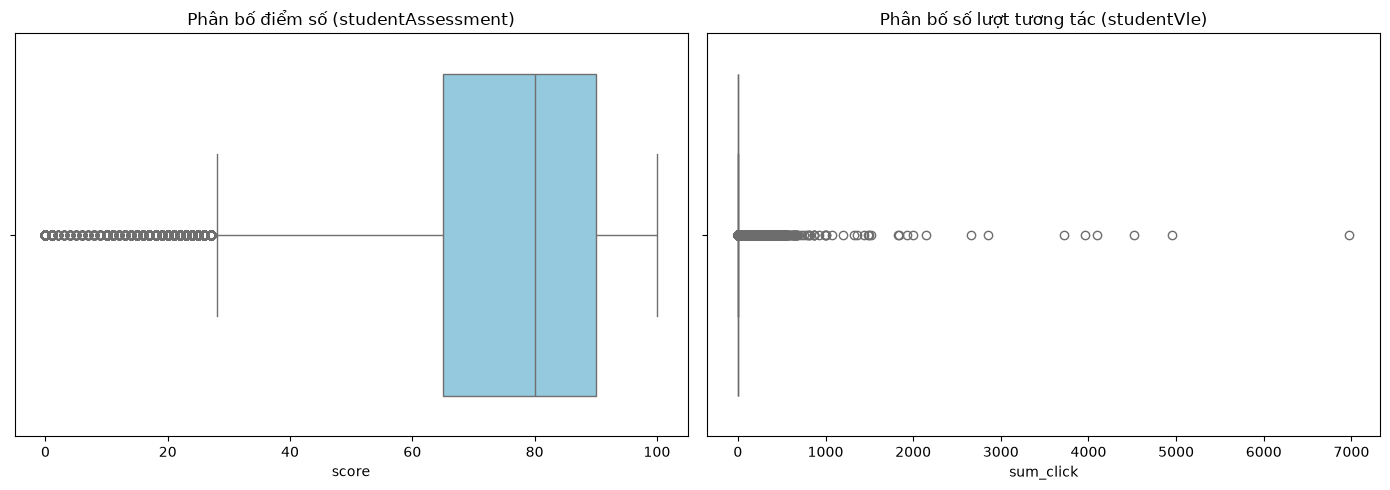

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot cho score
sns.boxplot(data=student_assessment, x='score', ax=axes[0], color='skyblue')
axes[0].set_title('Phân bố điểm số (studentAssessment)')

# Boxplot cho sum_click
sns.boxplot(data=student_vle, x='sum_click', ax=axes[1], color='salmon')
axes[1].set_title('Phân bố số lượt tương tác (studentVle)')

plt.tight_layout()
plt.show()

### 3.3. Đánh giá & Nhận xét về Giá trị Bất thường (Outliers)

1. **Điểm số (`score`):**
   - Tất cả giá trị điểm số nằm trong khoảng hợp lệ $[0, 100]$. Không xuất hiện điểm âm hay điểm $>100$.
   - Một số điểm 0 xuất hiện do sinh viên không đạt yêu cầu/bỏ bài, đây là giá trị hợp lý về mặt nghiệp vụ.

2. **Lượt tương tác trên hệ thống VLE (`sum_click`):**
   - Xuất hiện nhiều giá trị ngoại lệ (outliers) nằm phía bên phải boxplot (có những sinh viên click hàng nghìn lần).
   - **Đánh giá:** Các giá trị này đại diện cho những sinh viên cực kỳ tích cực tương tác trên hệ thống trực tuyến, không phải do lỗi nhập liệu.
   - **Xử lý:** Giữ lại dữ liệu thực tế này, nhưng trong bước Preprocessing sẽ áp dụng phép biến đổi Logarit (`np.log1p`) để chuẩn hóa phân bố.

## 4. Data Imbalance (Mất cân bằng dữ liệu)

### 4.1. Phân tích và phân bố mục tiêu

In [10]:
# 4.1. Tính toán số lượng và tỷ lệ % chi tiết của từng lớp trong final_result
count_result = student_info['final_result'].value_counts()
percent_result = student_info['final_result'].value_counts(normalize=True) * 100

# Tổng hợp thành DataFrame
target_distribution = pd.DataFrame({
    'Số lượng sinh viên': count_result,
    'Tỷ lệ (%)': percent_result.round(2)
})

print("--- THỐNG KÊ PHÂN BỐ BẤT CÂN BẰNG CỦA BIẾN MỤC TIÊU (final_result) ---")
display(target_distribution)

--- THỐNG KÊ PHÂN BỐ BẤT CÂN BẰNG CỦA BIẾN MỤC TIÊU (final_result) ---


,Số lượng sinh viên,Tỷ lệ (%)
final_result,,
Pass,12361,37.93
Withdrawn,10156,31.16
Fail,7052,21.64
Distinction,3024,9.28


### 4.2 Trực quan hoá tỷ lệ các lớp dữ liệu

C:\Users\Admin\AppData\Local\Temp\ipykernel_14464\2815929942.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


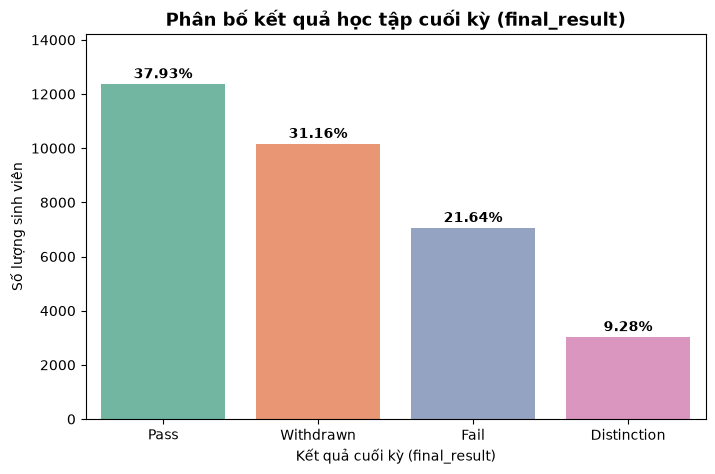

In [11]:
# 4.2. Vẽ biểu đồ countplot minh họa tỷ lệ các lớp dữ liệu
plt.figure(figsize=(8, 5))

# Biểu đồ đếm số lượng từng lớp
ax = sns.countplot(
    data=student_info, 
    x='final_result', 
    order=['Pass', 'Withdrawn', 'Fail', 'Distinction'], 
    palette='Set2'
)

plt.title('Phân bố kết quả học tập cuối kỳ (final_result)', fontsize=13, fontweight='bold')
plt.xlabel('Kết quả cuối kỳ (final_result)')
plt.ylabel('Số lượng sinh viên')

# Hiển thị phần trăm cụ thể trên đầu từng cột
total = len(student_info)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + 100
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylim(0, max(student_info['final_result'].value_counts()) * 1.15)
plt.show()

### 4.3. Đánh giá về Mất cân bằng Dữ liệu (Data Imbalance) & Tác động ML

| Nhóm kết quả (`final_result`) | Tỷ lệ (%) | Nhận xét phân bố |
| :--- | :---: | :--- |
| **Pass** (Đạt) | ~37% | Lớp chiếm tỷ lệ lớn nhất. |
| **Withdrawn** (Rút lui) | ~31% | Tỷ lệ sinh viên bỏ học/rút môn khá cao. |
| **Fail** (Trượt) | ~22% | Lớp thiểu số thứ 2. |
| **Distinction** (Xuất sắc) | ~9% | Lớp thiểu số nhất. |

> **Tác động đến Mô hình Machine Learning & Hướng giải quyết:**
> - **Hiện tượng:** Dữ liệu có sự mất cân bằng rõ rệt giữa lớp xuất sắc (`Distinction` ~9%) và các lớp khác.
> - **Nguy cơ:** Mô hình học máy dễ bị thiên vị (bias) sang lớp đa số (`Pass`/`Withdrawn`) và dễ đoán sai lớp thiểu số.
> - **Định hướng ở bước Preprocessing/Modeling:**
>   1. Gộp lớp nếu bài toán là Phân loại Nhị phân (Binary Classification): `Pass` + `Distinction` (Đạt) vs `Fail` + `Withdrawn` (Không đạt).
>   2. Sử dụng thang đo đánh giá phù hợp: Ưu tiên `Macro F1-Score`, `Precision-Recall AUC` thay vì chỉ dựa vào `Accuracy`.
>   3. Áp dụng kỹ thuật cân bằng lớp như `SMOTE` hoặc điều chỉnh `class_weight='balanced'` khi huấn luyện mô hình.